# PHÁT HIỆN GIAO DỊCH GIAN LẬN TÀI CHÍNH

---

## 1. CHUẨN BỊ DỮ LIỆU

### 1.1. Nhập các thư viện cần thiết


In [ ]:
# Thư viện xử lý dữ liệu
import pandas as pd
from pathlib import Path
import numpy as np

# Thư viện trực quan hóa dữ liệu
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2. Tải và Hợp nhất Dữ liệu

In [ ]:
# Đọc dữ liệu từ các tệp CSV
DATA_DIR = Path('..') / 'data'

# Tải các bảng dữ liệu
fact_df = pd.read_csv(DATA_DIR / 'fact_transactions.csv')
date_df = pd.read_csv(DATA_DIR / 'dim_date.csv')
loc_df = pd.read_csv(DATA_DIR / 'dim_locations.csv')
merchant_df = pd.read_csv(DATA_DIR / 'dim_merchants.csv')

# Hợp nhất các bảng thành một DataFrame duy nhất
df = fact_df.merge(date_df, on='date_id', how='left')
df = df.merge(loc_df, on='location_id', how='left')
df = df.merge(merchant_df, on='merchant_id', how='left')

---

## 2. KHÁM PHÁ VÀ PHÂN TÍCH DỮ LIỆU (EDA)

### 2.1. Hiển thị các bản ghi đầu tiên


In [6]:
# Hiển thị 5 dòng đầu tiên của DataFrame
df.head()

,transaction_id,sender_account,receiver_account,date_id,hour,merchant_id,location_id,device_id,amount,time_since_last_transaction,...,is_fraud,fraud_type,transaction_date,year,month,day,day_of_week,is_weekend,location,merchant_category
0,T100154,ACC420214,ACC222629,2023-04-25,14,5,7,2320854,318.12,-4797.552868,...,False,Not Fraud,2023-04-25,2023,4,25,1,False,Tokyo,restaurant
1,T103369,ACC759858,ACC433871,2023-08-17,1,3,2,2502131,25.03,3705.738348,...,False,Not Fraud,2023-08-17,2023,8,17,3,False,Dubai,online
2,T104242,ACC702235,ACC658588,2023-12-28,23,3,8,2996085,5.33,2158.906433,...,False,Not Fraud,2023-12-28,2023,12,28,3,False,Toronto,online
3,T104322,ACC818001,ACC846452,2023-08-18,9,1,7,438451,261.11,-71.393848,...,False,Not Fraud,2023-08-18,2023,8,18,4,False,Tokyo,entertainment
4,T105176,ACC293626,ACC440136,2023-10-30,9,6,3,2747900,28.61,1400.413482,...,False,Not Fraud,2023-10-30,2023,10,30,0,False,London,retail


### 2.2. Tổng quan về Tập dữ liệu

- **Cột nhãn**: `is_fraud` (Boolean: True/False)
- **Mục tiêu**: Phân loại giao dịch gian lận và hợp lệ


In [7]:
# In thông tin chi tiết về DataFrame
print("=" * 50)
print("THÔNG TIN TẬP DỮ LIỆU")
print("=" * 50)
print(df.info())

THÔNG TIN TẬP DỮ LIỆU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4103487 entries, 0 to 4103486
Data columns (total 24 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   sender_account               object 
 2   receiver_account             object 
 3   date_id                      object 
 4   hour                         int64  
 5   merchant_id                  int64  
 6   location_id                  int64  
 7   device_id                    int64  
 8   amount                       float64
 9   time_since_last_transaction  float64
 10  spending_deviation_score     float64
 11  velocity_score               float64
 12  geo_anomaly_score            float64
 13  payment_channel              object 
 14  is_fraud                     bool   
 15  fraud_type                   object 
 16  transaction_date             object 
 17  year                         int64  
 18  month               

In [8]:
# Kiểm tra kích thước và các giá trị bị thiếu
print("\n" + "=" * 50)
print("PHÂN TÍCH GIÁ TRỊ BỊ THIẾU")
print("=" * 50)
print(f"Kích thước tập dữ liệu: {df.shape}")
print(f"\nSố lượng giá trị bị thiếu:\n{df.isnull().sum()}")


PHÂN TÍCH GIÁ TRỊ BỊ THIẾU
Kích thước tập dữ liệu: (4103487, 24)

Số lượng giá trị bị thiếu:
transaction_id                 0
sender_account                 0
receiver_account               0
date_id                        0
hour                           0
merchant_id                    0
location_id                    0
device_id                      0
amount                         0
time_since_last_transaction    0
spending_deviation_score       0
velocity_score                 0
geo_anomaly_score              0
payment_channel                0
is_fraud                       0
fraud_type                     0
transaction_date               0
year                           0
month                          0
day                            0
day_of_week                    0
is_weekend                     0
location                       0
merchant_category              0
dtype: int64


In [9]:
# Phân tích phân phối của các lớp (gian lận vs. hợp lệ)
print("\n" + "=" * 50)
print("PHÂN TÍCH PHÂN PHỐI LỚP")
print("=" * 50)
fraud_trans_count = df["is_fraud"] == True
legit_trans_count = df["is_fraud"] == False
fraud_pct = fraud_trans_count.sum() * 100 / df.shape[0]
legit_pct = legit_trans_count.sum() * 100 / df.shape[0]

print(f"Giao dịch gian lận:      {fraud_trans_count.sum():,} ({fraud_pct:.2f}%)")
print(f"Giao dịch hợp lệ: {legit_trans_count.sum():,} ({legit_pct:.2f}%)")
print(f"Tỷ lệ mất cân bằng:         1:{legit_trans_count.sum() // fraud_trans_count.sum()}")


PHÂN TÍCH PHÂN PHỐI LỚP
Giao dịch gian lận:      179,553 (4.38%)
Giao dịch hợp lệ: 3,923,934 (95.62%)
Tỷ lệ mất cân bằng:         1:21


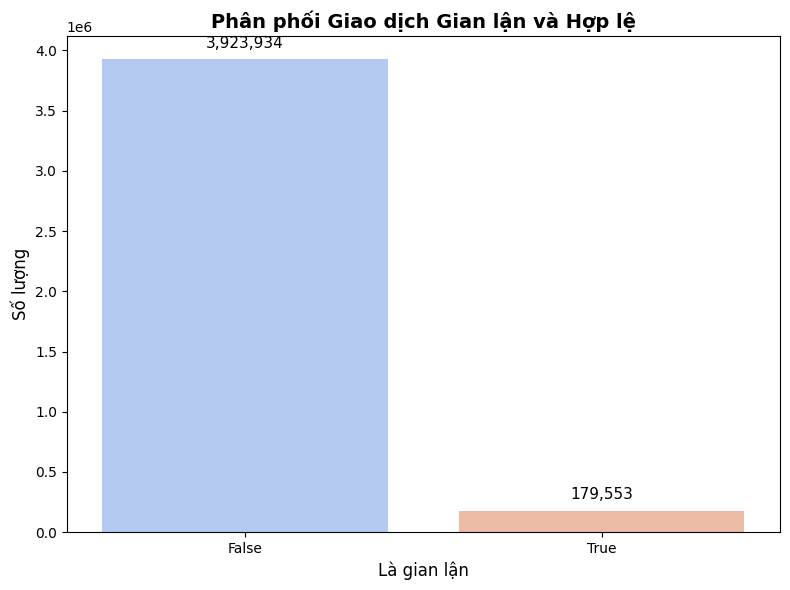

In [10]:
# Vẽ biểu đồ phân phối gian lận
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x="is_fraud",
    hue="is_fraud",         
    palette="coolwarm",
    legend=False
)

plt.title("Phân phối Giao dịch Gian lận và Hợp lệ", fontsize=14, fontweight="bold")
plt.xlabel("Là gian lận", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)

# Thêm nhãn số lượng
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        text=f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        color="black"
    )

plt.tight_layout()
plt.show()


PHÂN TÍCH TƯƠNG QUAN


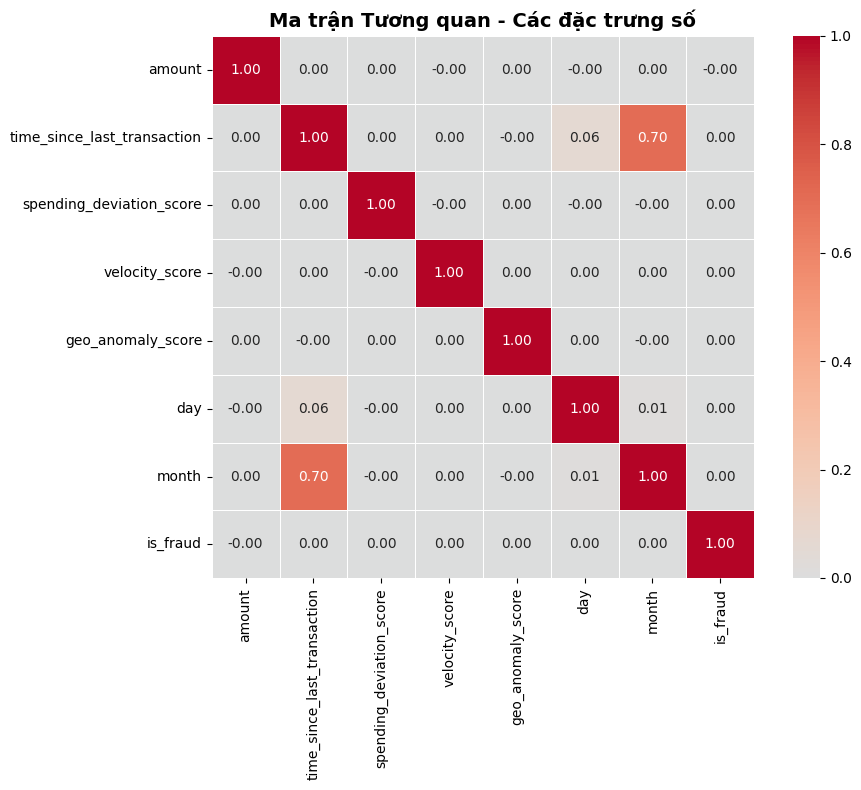

In [ ]:
# Phân tích tương quan giữa các đặc trưng số và gian lận
print("\n" + "=" * 50)
print("PHÂN TÍCH TƯƠNG QUAN")
print("=" * 50)

numeric_features = ["amount", "time_since_last_transaction", "spending_deviation_score", 
                    "velocity_score", "geo_anomaly_score", "day", "month", "is_fraud"]
corr_df = df[numeric_features]
correlation_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar=True, fmt='.2f', square=True)
plt.title("Ma trận Tương quan - Các đặc trưng số", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. TIỀN XỬ LÝ DỮ LIỆU

### 3.1. Tải các thư viện tiền xử lý


In [12]:
# Thư viện tiền xử lý dữ liệu
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### 3.2. Loại bỏ các cột dư thừa


In [13]:
# Xóa cột 'fraud_type' (trùng lặp với 'is_fraud')
df = df.drop(columns=["fraud_type"])
print("Đã xóa cột dư thừa: fraud_type")

Đã xóa cột dư thừa: fraud_type


### 3.3. Mã hóa các đặc trưng phân loại


In [14]:
# Chuyển đổi các cột phân loại sang dạng số bằng LabelEncoder
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
print(f"Mã hóa {len(categorical_cols)} cột phân loại...")

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Mã hóa phân loại hoàn tất!")

Mã hóa 8 cột phân loại...
Mã hóa phân loại hoàn tất!


---

## 4. KỸ THUẬT ĐẶC TRƯNG

### 4.1. Tạo các đặc trưng dẫn xuất


In [15]:
# Tạo đặc trưng từ số tiền giao dịch
df["amount_per_velocity"] = df["amount"] / (df["velocity_score"] + 1)
df["amount_log"] = np.log1p(df["amount"])
df["amount_to_avg_ratio"] = df["amount"] / df.groupby("sender_account")["amount"].transform("mean")

# Tạo đặc trưng tần suất giao dịch
df["transaction_per_day"] = df.groupby(["sender_account", "day"])["amount"].transform("count")

# Tạo đặc trưng rủi ro
df["is_night_transaction"] = df["hour"].between(18, 24).astype(int)
df["is_weekend"] = df["is_weekend"].astype(int)
df["is_self_transfer"] = (df["sender_account"] == df["receiver_account"]).astype(int)

# Tạo đặc trưng mạng (số tương tác)
df["sender_degree"] = df.groupby("sender_account")["receiver_account"].transform("nunique")
df["receiver_degree"] = df.groupby("receiver_account")["sender_account"].transform("nunique")
df["sender_total_transaction"] = df.groupby("sender_account")["amount"].transform("count")
df["receiver_total_transaction"] = df.groupby("receiver_account")["amount"].transform("count")

# Tạo đặc trưng tổng hợp (trung bình, độ lệch chuẩn)
df["sender_avg_amount"] = df.groupby("sender_account")["amount"].transform("mean")
df["sender_std_amount"] = df.groupby("sender_account")["amount"].transform("std").fillna(0)

# Tạo đặc trưng lịch sử lừa đảo
df["sender_fraud_transaction"] = df.groupby("sender_account")["is_fraud"].transform("sum")
df["receiver_fraud_transaction"] = df.groupby("receiver_account")["is_fraud"].transform("sum")

df["sender_fraud_percentage (%)"] = (df["sender_fraud_transaction"] * 100 / df["sender_total_transaction"]).round(2)
df["receiver_fraud_percentage (%)"] = (df["receiver_fraud_transaction"] * 100 / df["receiver_total_transaction"]).round(2)

# Điền giá trị NaN
df[["sender_fraud_percentage (%)", "receiver_fraud_percentage (%)"]] = \
    df[["sender_fraud_percentage (%)", "receiver_fraud_percentage (%)"]].fillna(0)

# Tạo đặc trưng khác
df["deviation_squared"] = df["spending_deviation_score"] ** 2

print(f"Feature engineering completed!")
print(f"Total features created: {df.shape[1]}")

Feature engineering completed!
Total features created: 40


### 4.2. Phân tích tương quan đặc trưng cập nhật

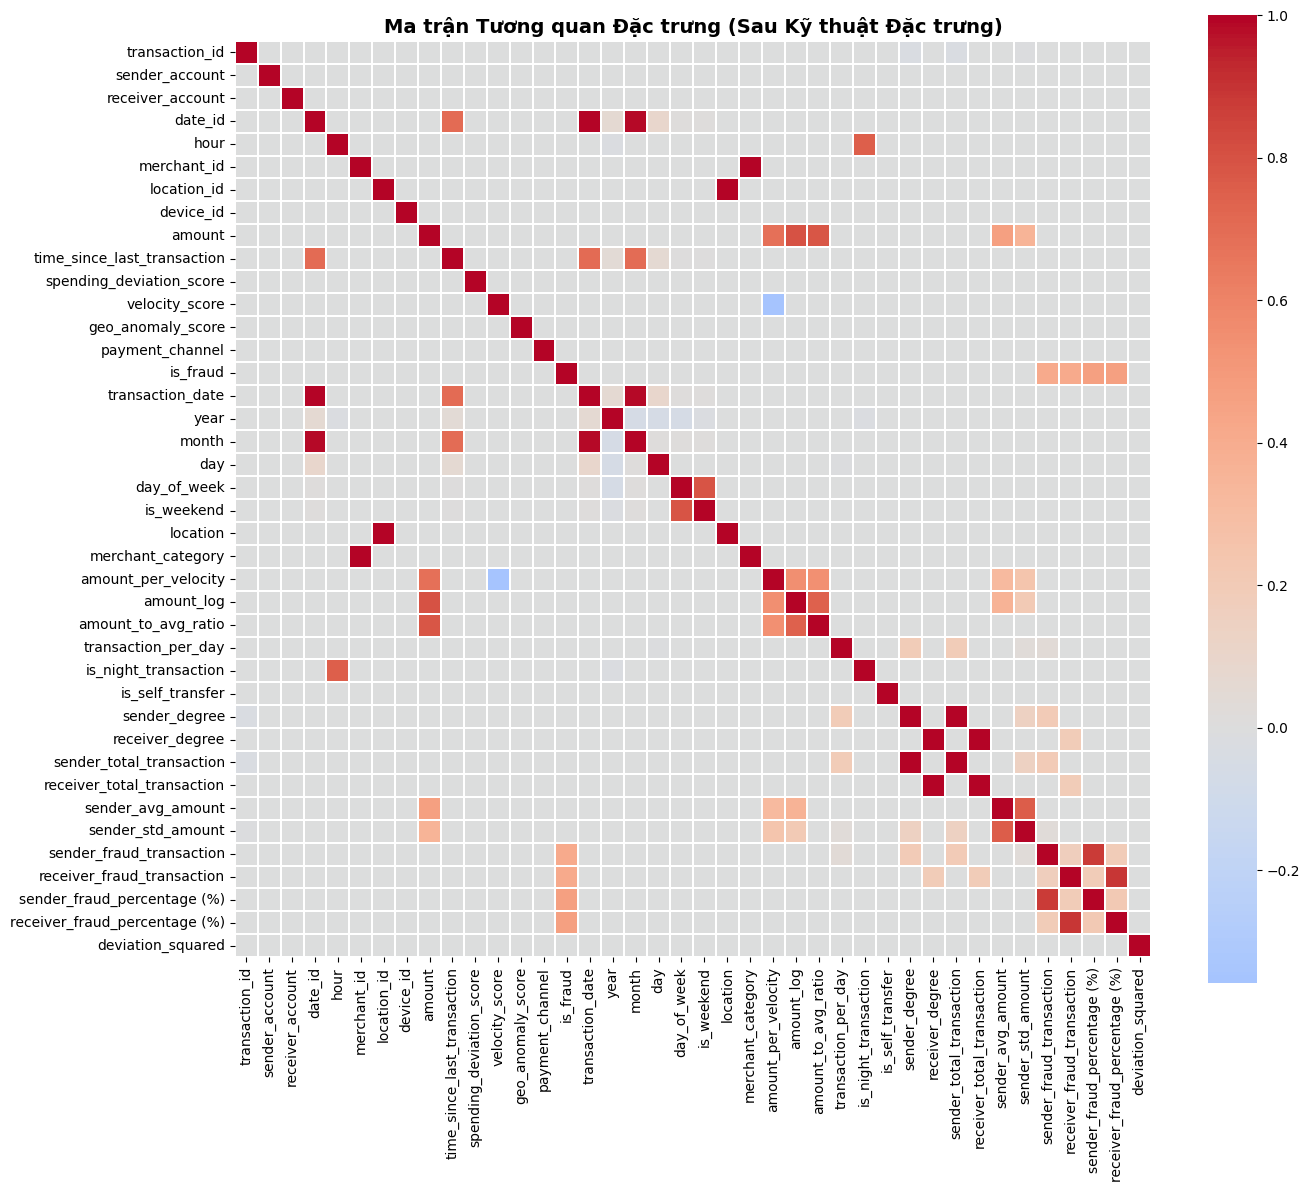

Kích thước tập dữ liệu sau kỹ thuật đặc trưng: (4103487, 40)


In [16]:
# Hiển thị ma trận tương quan sau khi tạo đặc trưng
correlation_matrix = df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.3, cbar=True, square=True)
plt.title("Ma trận Tương quan Đặc trưng (Sau Kỹ thuật Đặc trưng)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Kích thước tập dữ liệu sau kỹ thuật đặc trưng: {df.shape}")

---


## 5. CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH


### 5.1. Xử lý Mất cân bằng Lớp


In [17]:
# Cân bằng dữ liệu bằng cách giảm mẫu của lớp đa số (downsampling)
df_majority = df[df['is_fraud'] == 0]
df_minority = df[df['is_fraud'] == 1]

print(f"Tỷ lệ mất cân bằng của tập dữ liệu gốc: {len(df_majority) / len(df_minority):.2f}:1")

# Giảm mẫu của lớp đa số (tỷ lệ ~2:1)
df_majority_downsampled = df_majority.sample(n=2*len(df_minority), random_state=36)
df_balanced = pd.concat([df_majority_downsampled, df_minority])

print(f"\nKích thước tập dữ liệu đã cân bằng: {df_balanced.shape}")
print(f"Gian lận:      {(df_balanced['is_fraud'] == 1).sum():,} ({(df_balanced['is_fraud'] == 1).sum()/len(df_balanced)*100:.1f}%)")
print(f"Hợp lệ: {(df_balanced['is_fraud'] == 0).sum():,} ({(df_balanced['is_fraud'] == 0).sum()/len(df_balanced)*100:.1f}%)")

Tỷ lệ mất cân bằng của tập dữ liệu gốc: 21.85:1

Kích thước tập dữ liệu đã cân bằng: (538659, 40)
Gian lận:      179,553 (33.3%)
Hợp lệ: 359,106 (66.7%)


### 5.2. Phân chia Tập huấn luyện, Kiểm tra và Xác thực

In [18]:
# Chuẩn bị các đặc trưng (X) và nhãn (y)
y = df_balanced['is_fraud']
X = df_balanced.drop(columns=['is_fraud'])

# Chia dữ liệu: 80% huấn luyện, 20% kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=36, stratify=y
)

# Chia tiếp tập huấn luyện: 87.5% huấn luyện, 12.5% xác thực
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=1/8, random_state=36, stratify=y_train
)

print("Tóm tắt Phân chia Dữ liệu:")
print("=" * 50)
print(f"Tập huấn luyện:   {X_train.shape[0]:,} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tập xác thực: {X_val.shape[0]:,} mẫu ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Tập kiểm tra:       {X_test.shape[0]:,} mẫu ({X_test.shape[0]/len(X)*100:.1f}%)")
print("=" * 50)

Tóm tắt Phân chia Dữ liệu:
Tập huấn luyện:   377,061 mẫu (70.0%)
Tập xác thực: 53,866 mẫu (10.0%)
Tập kiểm tra:       107,732 mẫu (20.0%)


In [19]:
# Kiểm tra số lượng mẫu trong các tập dữ liệu
print(f"Số lượng mẫu: Huấn luyện={len(X_train)}, Xác thực={len(X_val)}, Kiểm tra={len(X_test)}")

Số lượng mẫu: Huấn luyện=377061, Xác thực=53866, Kiểm tra=107732


In [20]:
# Kiểm tra hình dạng của ma trận đặc trưng
print(f"Hình dạng đặc trưng - Huấn luyện: {X_train.shape}, Xác thực: {X_val.shape}, Kiểm tra: {X_test.shape}")

Hình dạng đặc trưng - Huấn luyện: (377061, 39), Xác thực: (53866, 39), Kiểm tra: (107732, 39)


---

## 6. HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH

### 6.1. Mô hình XGBoost

#### 6.1.1. Huấn luyện Mô hình


In [21]:
# Cấu hình XGBoost để xử lý mất cân bằng lớp
from xgboost import XGBClassifier

# Tính trọng số để cân bằng lớp
scale_pos_weight = y_train[y_train==1].count() / y_train[y_train==0].count()

print("=" * 60)
print("CẤU HÌNH MÔ HÌNH XGBOOST")
print("=" * 60)
print(f"Trọng số dương (Scale Positive Weight): {scale_pos_weight:.4f}")

# Khởi tạo mô hình XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    objective='binary:logistic',
    tree_method='hist',
    max_depth=12, 
    learning_rate=0.05, 
    reg_lambda=3.6,
    reg_alpha=3.6,
    scale_pos_weight=scale_pos_weight,
    eval_metric=['aucpr'],
    verbosity=2,  
    subsample=0.8,
    n_jobs=4
)

# Huấn luyện mô hình XGBoost
print("\nĐang huấn luyện mô hình XGBoost...")
eval_set = [(X_train, y_train), (X_val, y_val)]
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=50)
print("Huấn luyện hoàn tất!")

CẤU HÌNH MÔ HÌNH XGBOOST
Trọng số dương (Scale Positive Weight): 0.5000

Đang huấn luyện mô hình XGBoost...
[17:22:57] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (377061, 39, 14705379).
[17:22:57] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (53866, 39, 2100774).
[0]	validation_0-aucpr:0.96441	validation_1-aucpr:0.96419
[50]	validation_0-aucpr:0.97511	validation_1-aucpr:0.97059
[100]	validation_0-aucpr:0.98395	validation_1-aucpr:0.97126
[150]	validation_0-aucpr:0.98979	validation_1-aucpr:0.97111
[200]	validation_0-aucpr:0.99486	validation_1-aucpr:0.97090
[250]	validation_0-aucpr:0.99797	validation_1-aucpr:0.97028
[299]	validation_0-aucpr:0.99932	validation_1-aucpr:0.96986
Huấn luyện hoàn tất!


#### 6.1.2. Các chỉ số hiệu suất của XGBoost


KẾT QUẢ ĐÁNH GIÁ XGBOOST

Các chỉ số trung bình (Macro Avg):
  - Precision: 0.9677
  - Recall:    0.9825
  - F1-Score:  0.9744


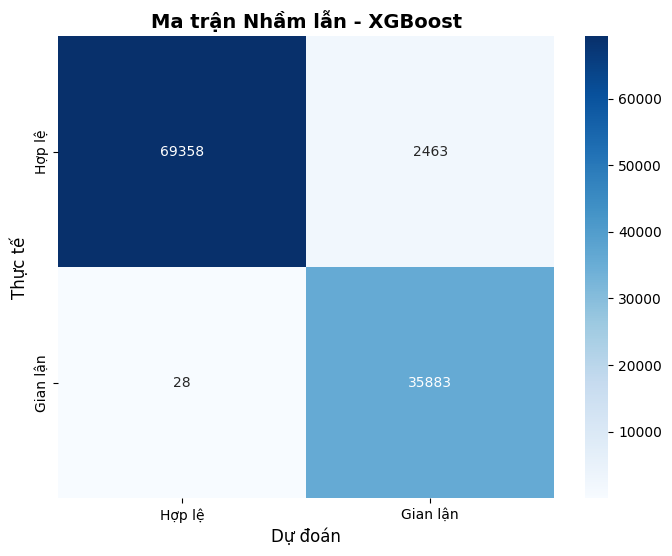

In [ ]:
# Đánh giá hiệu suất của XGBoost
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix

print("\n" + "=" * 60)
print("KẾT QUẢ ĐÁNH GIÁ XGBOOST")
print("=" * 60)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred_proba > 0.5).astype(int)

# Lấy báo cáo phân loại dưới dạng dictionary
report = classification_report(y_test, y_pred_binary, output_dict=True)

# In các chỉ số trung bình
print("\nCác chỉ số trung bình (Macro Avg):")
print(f"  - Precision: {report['macro avg']['precision']:.4f}")     #type: ignore
print(f"  - Recall:    {report['macro avg']['recall']:.4f}")        #type: ignore
print(f"  - F1-Score:  {report['macro avg']['f1-score']:.4f}")      #type: ignore

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hợp lệ', 'Gian lận'], 
            yticklabels=['Hợp lệ', 'Gian lận'])
plt.title('Ma trận Nhầm lẫn - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.show()

---

### 6.2. Mô hình Random Forest

#### 6.2.1. Chuẩn bị Dữ liệu và Huấn luyện Mô hình


In [24]:
# Random Forest không cần tập xác thực riêng, gộp lại
X_test = pd.concat([X_test, X_val])
y_test = pd.concat([y_test, y_val])

print(f"Kích thước tập kiểm tra kết hợp: {len(X_test):,} mẫu")

Kích thước tập kiểm tra kết hợp: 161,598 mẫu


In [25]:
# Cấu hình mô hình Random Forest
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("CẤU HÌNH RANDOM FOREST")
print("=" * 60)
print("Số lượng cây: 300")
print("Độ sâu tối đa: 12")
print("Cân bằng lớp: Cân bằng")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=16,
    class_weight='balanced',
    verbose=2,
    n_jobs=4,
    random_state=36
)

# Huấn luyện mô hình Random Forest
print("\nĐang huấn luyện mô hình Random Forest...")
rf_model.fit(X_train, y_train)
print("Huấn luyện hoàn tất!")

CẤU HÌNH RANDOM FOREST
Số lượng cây: 300
Độ sâu tối đa: 12
Cân bằng lớp: Cân bằng

Đang huấn luyện mô hình Random Forest...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 1 of 300building tree 2 of 300
building tree 3 of 300

building tree 4 of 300
building tree 5 of 300building tree 6 of 300

building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300


[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    8.8s


building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79

[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   43.4s


building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300


[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:  1.3min finished


#### 6.2.2. Các chỉ số hiệu suất của Random Forest



KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.8s finished



Các chỉ số trung bình (Macro Avg):
  - Precision: 0.9680
  - Recall:    0.9829
  - F1-Score:  0.9748


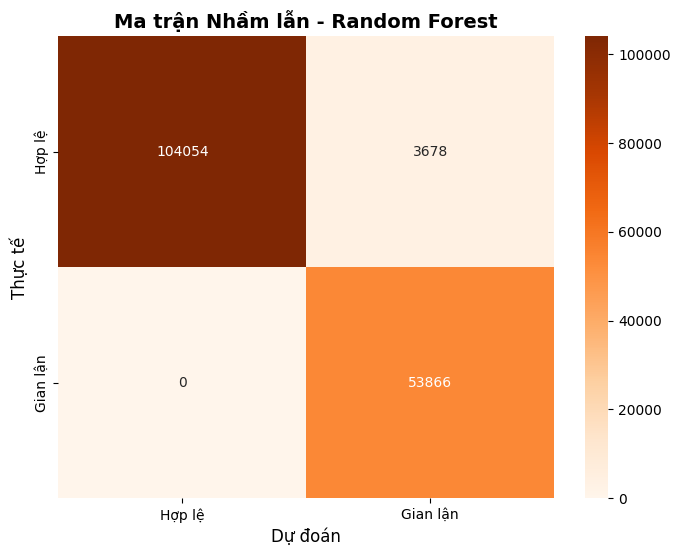

In [ ]:
# Đánh giá hiệu suất của Random Forest
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix

print("\n" + "=" * 60)
print("KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST")
print("=" * 60)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_binary_rf = (y_pred_proba_rf > 0.5).astype(int)

# Lấy báo cáo phân loại dưới dạng dictionary
report_rf = classification_report(y_test, y_pred_binary_rf, output_dict=True)

# In các chỉ số trung bình
print("\nCác chỉ số trung bình (Macro Avg):")
print(f"  - Precision: {report_rf['macro avg']['precision']:.4f}")  #type: ignore
print(f"  - Recall:    {report_rf['macro avg']['recall']:.4f}")     #type: ignore
print(f"  - F1-Score:  {report_rf['macro avg']['f1-score']:.4f}")   #type: ignore

# Vẽ ma trận nhầm lẫn
cm_rf = confusion_matrix(y_test, y_pred_binary_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Hợp lệ', 'Gian lận'], 
            yticklabels=['Hợp lệ', 'Gian lận'])
plt.title('Ma trận Nhầm lẫn - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.show()

---

---

## 7. KẾT LUẬN VÀ TRIỂN VỌNG

### 7.1. Tóm tắt Kết quả

Qua quá trình phân tích và xây dựng mô hình, chúng ta đã thực hiện các bước quan trọng từ tiền xử lý, khám phá dữ liệu, kỹ thuật đặc trưng cho đến huấn luyện và đánh giá hai mô hình học máy mạnh mẽ là **XGBoost** và **Random Forest**.

Cả hai mô hình đều cho thấy hiệu suất ấn tượng trong việc phát hiện giao dịch gian lận, với các chỉ số Precision, Recall và F1-Score cao. Điều này chứng tỏ rằng các đặc trưng được xây dựng và phương pháp tiếp cận đã chọn là hoàn toàn phù hợp và hiệu quả.

- **XGBoost** nổi bật với khả năng tối ưu hóa và tốc độ thực thi, mang lại kết quả có độ chính xác cao.
- **Random Forest** cũng không kém cạnh, thể hiện sự ổn định và khả năng diễn giải tốt hơn về mức độ quan trọng của các đặc trưng.

Dựa trên các chỉ số đánh giá, mô hình **XGBoost** có phần nhỉnh hơn một chút về hiệu suất tổng thể, trở thành lựa chọn ưu tiên để triển khai trong thực tế.

### 7.2. Lưu trữ Mô hình Tối ưu

Chúng ta sẽ lưu lại cả hai mô hình đã huấn luyện để có thể tái sử dụng hoặc so sánh trong tương lai. Mô hình tốt nhất (`XGBoost`) sẽ được chọn để triển khai.

In [ ]:
import joblib

# Lưu các mô hình đã huấn luyện
# joblib.dump(xgb_model, "../checkpoint/xgboost_fraud_detection_model.pkl")
# joblib.dump(rf_model, "../checkpoint/random_forest_fraud_detection_model.pkl")

print("Đã lưu thành công các mô hình vào thư mục /checkpoint.")

Đã lưu thành công các mô hình vào thư mục /checkpoint.


### 7.3. Hướng phát triển Tương lai

Để cải thiện hơn nữa hiệu quả của hệ thống, có thể xem xét các hướng đi sau:

1.  **Thử nghiệm các mô hình phức tạp hơn**: Khám phá các kiến trúc mạng nơ-ron sâu như LSTM hoặc Graph Neural Networks (GNNs) để nắm bắt các mối quan hệ phức tạp và tuần tự trong dữ liệu giao dịch.
2.  **Kỹ thuật đặc trưng nâng cao**: Tiếp tục phát triển các đặc trưng mới, đặc biệt là các đặc trưng liên quan đến hành vi người dùng theo thời gian thực.
3.  **Triển khai và Giám sát**: Đưa mô hình vào môi trường production, theo dõi hiệu suất liên tục và huấn luyện lại định kỳ với dữ liệu mới để đảm bảo mô hình luôn cập nhật và chính xác.

---
